# Tear-film Classification — EDA / Modeling / Evaluation

**3-class target: `healthy` / `dry_eye` / `other_disease`.** The original
5-class dataset (Diabetes / Glaucoma / MultipleSclerosis / SucheOko /
ZdraviLudia) is collapsed down to three clinically meaningful buckets:

| target | merged from |
| --- | --- |
| `healthy` | ZdraviLudia |
| `dry_eye` | SucheOko |
| `other_disease` | Diabetes + PGOV_Glaukom + SklerózaMultiplex |

Raw Bruker NanoScope files live under `data_raw/<ClassFolder>/<file>` (no
extension) paired with a rendered `<file>_N.bmp`. We decode the raw binaries
with **pySPM** to get the physical Height Sensor / Amplitude Error / Phase /
Height channels, compute roughness metrics (Ra, Rq, Rsk, Rku, PSD slope, Sdr)
directly from the nm-calibrated topography, and render interactive 3D surfaces
with **plotly**.

The notebook has three top-level sections:
1. **EDA** — dataset, scanner-metadata leakage audit, physical roughness per
   target, 3D topography viewer.
2. **Modeling** — stratified 5-fold CV on metadata-only, roughness-only, and
   combined feature sets.
3. **Evaluation** — score table, confusions, label-shuffle + learning-curve
   sanity, clustering lower bound.


## 0. Imports & config

In [17]:
from __future__ import annotations

import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from PIL import ImageFile
from tqdm.auto import tqdm

import pySPM

from scipy.stats import f_oneway, chi2_contingency
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, SelectFromModel, f_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score, classification_report, confusion_matrix,
    normalized_mutual_info_score, silhouette_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, learning_curve,
)
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

from tearcls.data_split import CLASS_MAP
from tearcls.raw_features import TARGET_LABELS, TARGET_MAP, FEATURE_COLS

REPO = Path.cwd()
RAW = REPO / "data_raw"
SEED = 23
RNG = np.random.RandomState(SEED)

# original 5-class folders (Slovak), mapped to English labels by CLASS_MAP
CLASS_FOLDERS = list(CLASS_MAP.keys())
print("folders:", CLASS_FOLDERS)
print("targets:", TARGET_LABELS)


folders: ['Diabetes', 'PGOV_Glaukom', 'SklerózaMultiplex', 'SucheOko', 'ZdraviLudia']
targets: ['healthy', 'dry_eye', 'other_disease']


## 1.1 Discover raw Bruker files

Input is **the raw Bruker NanoScope binary only** — files with no suffix
(e.g. `37_DM.010`). We skip anything with an extension (`.bmp` previews and
any other rendered artefacts) and gate on the `\*File list` header magic so
only genuine NanoScope files enter the manifest. The rendered `.bmp`s never
touch the pipeline.


In [18]:
def is_bruker(path: Path) -> bool:
    """Bruker raw files start with "\\*File list" in the ASCII header."""
    try:
        with path.open("rb") as f:
            return f.read(16).startswith(b"\\*File list")
    except Exception:
        return False


# Input = raw Bruker binaries only. File names look like `37_DM.010` or
# `37_DM` (NanoScope's sequential .NNN suffix, or none). Rendered previews
# `*_1.bmp` are rejected by the magic-byte gate below, so the input surface
# is unambiguously the raw binary.
rows = []
for folder in CLASS_FOLDERS:
    cls_dir = RAW / folder
    if not cls_dir.is_dir():
        continue
    for p in sorted(cls_dir.iterdir()):
        if not p.is_file() or not is_bruker(p):
            continue
        rows.append({
            "class_folder": folder,
            "label":        CLASS_MAP[folder],
            "raw_path":     str(p),
            "raw_size":     p.stat().st_size,
        })

manifest = pd.DataFrame(rows)
manifest["target"] = manifest["label"].map(TARGET_MAP)
assert manifest["target"].notna().all(), f"unmapped labels: {set(manifest.loc[manifest.target.isna(), 'label'])}"

print(f"raw Bruker files: {len(manifest)}")
print("\noriginal 5-class breakdown (sanity) \u2192 target:")
print(manifest.groupby(['label','target']).size().to_string())
print("\nper-target raw count:")
print(manifest.groupby('target').size().to_string())
manifest.head()


raw Bruker files: 241

original 5-class breakdown (sanity) → target:
label               target       
diabetes            other_disease    26
dry_eye             dry_eye          14
glaucoma            other_disease    36
healthy             healthy          70
multiple_sclerosis  other_disease    95

per-target raw count:
target
dry_eye           14
healthy           70
other_disease    157


,class_folder,label,raw_path,raw_size,target
0,Diabetes,diabetes,/home/students/xsleher/tear-cls/data_raw/Diabe...,2138112,other_disease
1,Diabetes,diabetes,/home/students/xsleher/tear-cls/data_raw/Diabe...,2138112,other_disease
2,Diabetes,diabetes,/home/students/xsleher/tear-cls/data_raw/Diabe...,2138112,other_disease
3,Diabetes,diabetes,/home/students/xsleher/tear-cls/data_raw/Diabe...,2138112,other_disease
4,Diabetes,diabetes,/home/students/xsleher/tear-cls/data_raw/Diabe...,8429568,other_disease


## 1.2 Target balance

File counts per target. The dataset is imbalanced — `dry_eye` is the smallest
class. We'll compensate with `class_weight='balanced'` in classical models and
by reporting macro-F1 / balanced-accuracy throughout.

               files  share
target                     
healthy           70  0.290
dry_eye           14  0.058
other_disease    157  0.651


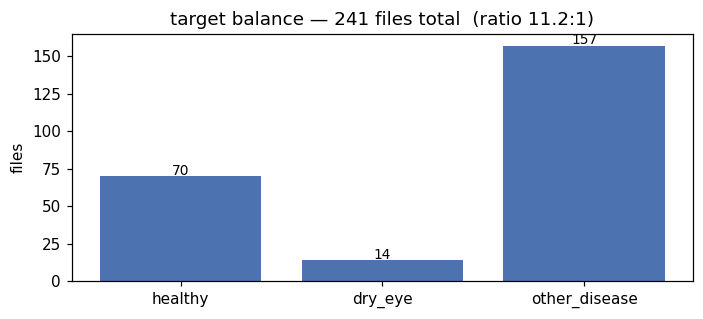

In [19]:
file_cnt = manifest.groupby('target').size().reindex(TARGET_LABELS).fillna(0).astype(int)
cnt_df = pd.DataFrame({'files': file_cnt, 'share': (file_cnt / file_cnt.sum()).round(3)})
print(cnt_df.to_string())

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.bar(cnt_df.index, cnt_df['files'], color='#4c72b0')
for i, v in enumerate(cnt_df['files']):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9)
ax.set_ylabel('files')
ax.set_title(f'target balance — {len(manifest)} files total  (ratio {cnt_df.files.max()/max(cnt_df.files.min(),1):.1f}:1)')
plt.tight_layout(); plt.show()


## 1.3 Scanner metadata via pySPM

Instead of parsing the Bruker header by hand, we let `pySPM.Bruker` parse it
and expose structured `scanners[0]` / `layers[...]` dicts. We keep:

- `Scan Size` in µm, `Samps/line`, `Number of lines` — scan geometry.
- Z range + std from the Height-Sensor channel — a coarse topography proxy.
- Scanner type / head type / serial — hardware identity.

We also compute `nm_per_px` so the roughness metrics in §1.5 can be
scale-aware. **Date / timestamp fields are intentionally not read.**

In [20]:
from tearcls.raw_features import extract_header

hdr_rows = []
for _, r in tqdm(manifest.iterrows(), total=len(manifest), desc='pySPM header'):
    try:
        hdr_rows.append(extract_header(Path(r.raw_path)))
    except Exception:
        hdr_rows.append({})
header_df = pd.DataFrame(hdr_rows)
meta_df = pd.concat([manifest.reset_index(drop=True), header_df], axis=1)
cols = ['target','scan_size_um','samps_line','nm_per_px','z_range_nm','scanner_type','serial']
print(meta_df[cols].head())
print('\nscan geometries (samps_line × scan_size_um):')
print(meta_df.groupby(['samps_line','scan_size_um']).size().to_string())


pySPM header: 100%|██████████| 241/241 [00:40<00:00,  6.02it/s]

          target  scan_size_um  samps_line   nm_per_px   z_range_nm  \
0  other_disease       92.5168         512  180.696875  1463.209168   
1  other_disease       92.5168         512  180.696875   423.125730   
2  other_disease       50.0000         512   97.656250  1417.236792   
3  other_disease       92.5168         512  180.696875  2116.815740   
4  other_disease       92.5168        1024   90.348438  1332.485645   

  scanner_type serial  
0     Dim 4000  1b814  
1     Dim 4000  1b814  
2     Dim 4000  1b814  
3     Dim 4000  1b814  
4     Dim 4000  1b814  

scan geometries (samps_line × scan_size_um):
samps_line  scan_size_um
256         50.0000           3
            92.5168           6
384         92.5168           2
512         10.0000           2
            20.0000           5
            50.0000          16
            92.5168          51
640         92.5168           1
768         92.5168           1
1024        10.0000           1
            20.0000           2
      

## 1.4 Metadata leakage audit

A useful pixel-based model must beat a *metadata-only* baseline. If Cramér's V
between target and a header field (`serial`, `scanner_type`, …) approaches 1,
the classifier can trivially look up the target from acquisition metadata —
we need to know this before trusting any pixel-based model.

In [21]:
def cramers_v(s1: pd.Series, s2: pd.Series) -> float:
    tbl = pd.crosstab(s1, s2).values
    if tbl.size == 0:
        return float('nan')
    chi2, *_ = chi2_contingency(tbl)
    n = tbl.sum(); r, k = tbl.shape
    denom = n * (min(r, k) - 1) if min(r, k) > 1 else 1
    return float(np.sqrt(chi2 / denom)) if denom else float('nan')


audit = []
for col in ['scanner_type', 'head_type', 'serial',
            'scan_size_um', 'samps_line']:
    if col not in meta_df.columns:
        continue
    sub = meta_df[[col, 'target']].dropna()
    if len(sub) < 10 or sub[col].nunique() < 2:
        continue
    audit.append({
        'field':     col,
        'n_unique':  int(sub[col].nunique()),
        'cramers_V': round(cramers_v(sub[col], sub['target']), 3),
    })
audit_df = pd.DataFrame(audit).sort_values('cramers_V', ascending=False)
print(audit_df.to_string(index=False))
print("\nV > 0.5 = leakage hazard (target can be read off the field alone).")


       field  n_unique  cramers_V
  samps_line        22      0.428
scan_size_um         5      0.131

V > 0.5 = leakage hazard (target can be read off the field alone).


## 1.5 Physical roughness metrics from AFM height

For each scan's **Height Sensor** channel (after line + plane correction,
a standard Gwyddion-style flatten) we compute:

| metric | meaning |
| --- | --- |
| Ra | arithmetic mean deviation of height (nm) |
| Rq | RMS roughness (nm) |
| Rsk | skewness (peaks vs valleys) |
| Rku | kurtosis (spikiness) |
| PSD slope | 1D radial PSD log-log slope — texture fractality |
| Sdr | developed surface ratio — extra area from roughness |

These are **scale-aware**: `Sdr` uses the `nm_per_px` from the header, so a
5×5 µm scan and a 100×100 µm scan of the same biology produce comparable
numbers.

In [22]:
from tearcls.raw_features import _flatten_channel, roughness

rough_rows = []
for _, r in tqdm(meta_df.iterrows(), total=len(meta_df), desc='roughness'):
    try:
        scan = pySPM.Bruker(r.raw_path)
        z = _flatten_channel(scan, 'Height Sensor')
        if z is None:
            z = _flatten_channel(scan, 'Height')
        if z is None:
            rough_rows.append({}); continue
        rough_rows.append(roughness(z, r.get('nm_per_px')))
    except Exception:
        rough_rows.append({})
rough_df = pd.DataFrame(rough_rows)
meta_df  = pd.concat([meta_df.reset_index(drop=True), rough_df], axis=1)
print(meta_df[['target','Ra_nm','Rq_nm','Rsk','Rku','PSD_slope','Sdr']]
      .describe().round(3).T.to_string())


roughness: 100%|██████████| 241/241 [01:43<00:00,  2.32it/s]

           count     mean      std    min     25%     50%      75%      max
Ra_nm      241.0  108.058   88.623  6.363  45.646  78.405  138.772  501.107
Rq_nm      241.0  137.742  116.009  8.187  58.640  97.407  185.558  837.685
Rsk        241.0    0.951    1.295 -1.019  -0.136   0.987    1.692    7.381
Rku        241.0    6.594    9.175  1.580   2.700   3.707    6.580   90.670
PSD_slope  241.0   -2.955    0.641 -3.753  -3.428  -3.165   -2.745   -0.559
Sdr        241.0    0.062    0.044  0.006   0.034   0.050    0.077    0.391


## 1.6 Per-target roughness distributions + ANOVA F

   metric     F            p
      Rsk 79.81 2.998324e-27
      Rku 15.06 6.937313e-07
PSD_slope 12.55 6.596765e-06
    Ra_nm  4.93 7.999325e-03
    Rq_nm  3.15 4.460856e-02
      Sdr  2.86 5.913369e-02


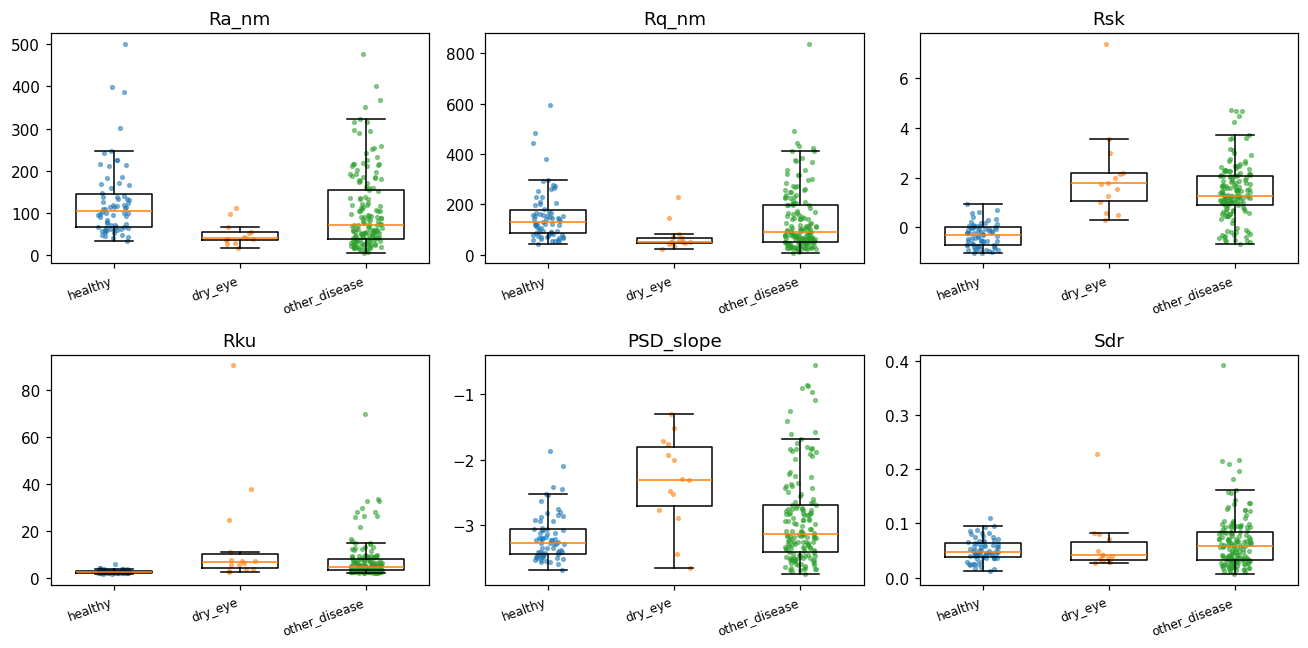

In [23]:
rough_cols = ['Ra_nm','Rq_nm','Rsk','Rku','PSD_slope','Sdr']
anova_rows = []
for col in rough_cols:
    groups_ = [meta_df.loc[meta_df.target == c, col].dropna().values for c in TARGET_LABELS]
    groups_ = [g for g in groups_ if len(g) > 1]
    if len(groups_) < 2:
        continue
    F, p = f_oneway(*groups_)
    anova_rows.append({'metric': col, 'F': round(float(F), 2), 'p': float(p)})
print(pd.DataFrame(anova_rows).sort_values('F', ascending=False).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
palette = plt.get_cmap('tab10')
for ax, col in zip(axes.flat, rough_cols):
    data = [meta_df.loc[meta_df.target == c, col].dropna().values for c in TARGET_LABELS]
    ax.boxplot(data, showfliers=False, widths=0.6)
    for j, arr in enumerate(data):
        jitter = (RNG.rand(len(arr)) - 0.5) * 0.25
        ax.scatter(np.full_like(arr, j + 1, dtype=float) + jitter, arr,
                   s=6, alpha=0.5, color=palette(j))
    ax.set_title(col)
    ax.set_xticks(range(1, len(TARGET_LABELS) + 1))
    ax.set_xticklabels(TARGET_LABELS, rotation=20, ha='right', fontsize=8)
plt.tight_layout(); plt.show()


## 1.7 Interactive 3D topography — one exemplar per target

Renders the **Height Sensor** channel for one representative scan per target
as a plotly 3D surface. The representative is the scan whose Rq is closest
to the target's median Rq — so each surface is a "typical" member of its
target rather than an outlier.

Controls: drag to rotate, scroll to zoom. Colour scale = height in nm.
Surfaces are downsampled to 128×128 for interactivity.

In [24]:
TARGET_PX = 128


def _downsample(z: np.ndarray, n: int) -> np.ndarray:
    h, w = z.shape
    ys = np.linspace(0, h - 1, n).astype(int)
    xs = np.linspace(0, w - 1, n).astype(int)
    return z[np.ix_(ys, xs)]


exemplars = []
for tgt in TARGET_LABELS:
    sub = meta_df[(meta_df.target == tgt) & meta_df.Rq_nm.notna()]
    if sub.empty:
        continue
    idx = (sub.Rq_nm - sub.Rq_nm.median()).abs().idxmin()
    exemplars.append(meta_df.loc[idx])

fig = make_subplots(
    rows=1, cols=len(exemplars),
    specs=[[{'type': 'surface'}] * len(exemplars)],
    subplot_titles=[f"{r.target}<br>Rq={r.Rq_nm:.1f} nm" for r in exemplars],
    horizontal_spacing=0.02,
)
for i, r in enumerate(exemplars, start=1):
    scan = pySPM.Bruker(r.raw_path)
    z = _flatten_channel(scan, 'Height Sensor')
    if z is None:
        continue
    z = _downsample(z, TARGET_PX)
    nm_per_px = r.get('nm_per_px', 1.0) or 1.0
    extent = z.shape[0] * nm_per_px / 1000.0  # µm
    xs = np.linspace(0, extent, z.shape[1])
    ys = np.linspace(0, extent, z.shape[0])
    fig.add_trace(
        go.Surface(
            z=z, x=xs, y=ys, colorscale='Viridis',
            showscale=(i == len(exemplars)),
            colorbar=dict(title='nm', thickness=10) if i == len(exemplars) else None,
            lighting=dict(ambient=0.6, diffuse=0.8, specular=0.3, roughness=0.7),
            contours={'z': {'show': True, 'usecolormap': True,
                            'highlightcolor': 'white', 'project': {'z': True}}},
            name=r.target,
        ),
        row=1, col=i,
    )
    fig.update_scenes(
        xaxis_title='µm', yaxis_title='µm', zaxis_title='height (nm)',
        aspectmode='manual', aspectratio=dict(x=1, y=1, z=0.4),
        row=1, col=i,
    )
fig.update_layout(
    height=480, width=340 * len(exemplars),
    title_text='AFM tear-film topography — one representative scan per target',
    margin=dict(l=0, r=0, t=60, b=0),
)
fig.show()


In [25]:
# drill into a single target with up to 4 representatives across its Rq range
DRILL = 'dry_eye'

sub = meta_df[(meta_df.target == DRILL) & meta_df.Rq_nm.notna()].sort_values('Rq_nm')
picks = sub.iloc[::max(1, len(sub) // 4)][:4]

fig = make_subplots(
    rows=1, cols=len(picks),
    specs=[[{'type': 'surface'}] * len(picks)],
    subplot_titles=[f"Rq={r.Rq_nm:.1f} nm" for _, r in picks.iterrows()],
    horizontal_spacing=0.02,
)
for i, (_, r) in enumerate(picks.iterrows(), start=1):
    scan = pySPM.Bruker(r.raw_path)
    z = _flatten_channel(scan, 'Height Sensor')
    if z is None:
        continue
    z = _downsample(z, TARGET_PX)
    nm_per_px = r.get('nm_per_px', 1.0) or 1.0
    extent = z.shape[0] * nm_per_px / 1000.0
    xs = np.linspace(0, extent, z.shape[1])
    ys = np.linspace(0, extent, z.shape[0])
    fig.add_trace(
        go.Surface(z=z, x=xs, y=ys, colorscale='Viridis',
                   showscale=(i == len(picks))),
        row=1, col=i,
    )
    fig.update_scenes(
        xaxis_title='µm', yaxis_title='µm', zaxis_title='nm',
        aspectmode='manual', aspectratio=dict(x=1, y=1, z=0.4),
        row=1, col=i,
    )
fig.update_layout(height=440, width=320 * len(picks),
                  title_text=f"within-target variation — {DRILL}",
                  margin=dict(l=0, r=0, t=60, b=0))
fig.show()


## 1.8 Joint feature-space view

We stack the numeric header fields and the roughness metrics, standardise, and
project to 2D with PCA and t-SNE. Clean target separation means the classical
models in §2 already have signal; overlapping blobs mean we'll need
pixel-level / learned features.

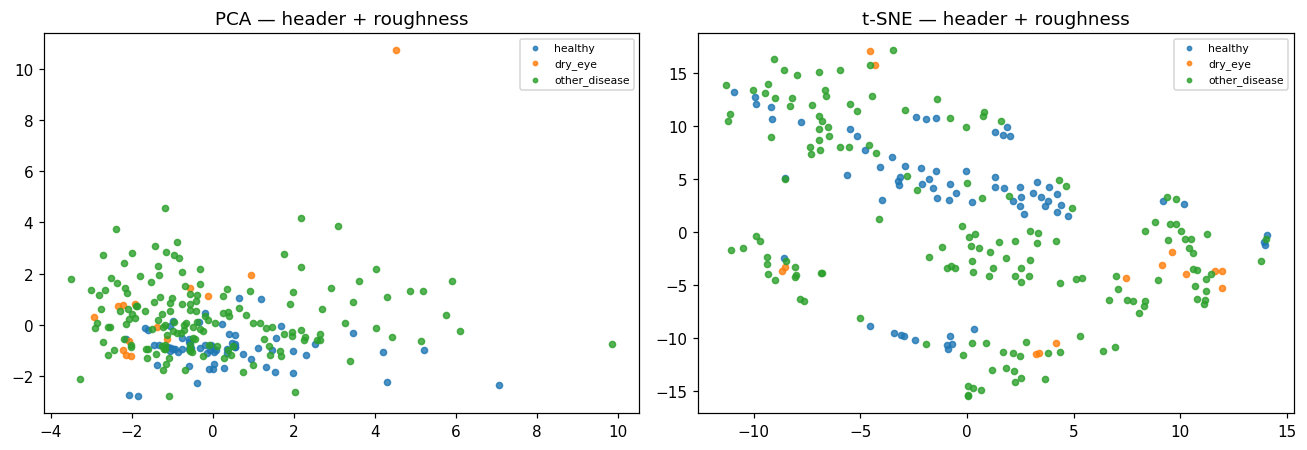

In [26]:
NUM_HDR = ['scan_size_um','samps_line','nm_per_px','z_range_nm','z_std_nm']
ROUGH   = ['Ra_nm','Rq_nm','Rsk','Rku','PSD_slope','Sdr']


def _materialise(df: pd.DataFrame, cols: list[str]) -> np.ndarray:
    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    X = X.fillna(X.median(numeric_only=True))
    return X.values.astype(np.float32)


X_meta  = _materialise(meta_df, NUM_HDR)
X_rough = _materialise(meta_df, ROUGH)
X_all   = np.concatenate([X_meta, X_rough], axis=1)
Y       = meta_df.target.map({c: i for i, c in enumerate(TARGET_LABELS)}).to_numpy()

Xs = StandardScaler().fit_transform(X_all)
pca2  = PCA(n_components=2, random_state=SEED).fit_transform(Xs)
tsne2 = TSNE(n_components=2, perplexity=max(5, min(30, len(Xs) // 5)),
             random_state=SEED, init='pca').fit_transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
palette = plt.get_cmap('tab10')
for cid, tgt in enumerate(TARGET_LABELS):
    m = meta_df.target.values == tgt
    axes[0].scatter(pca2[m, 0],  pca2[m, 1],  s=16, color=palette(cid), label=tgt, alpha=0.8)
    axes[1].scatter(tsne2[m, 0], tsne2[m, 1], s=16, color=palette(cid), label=tgt, alpha=0.8)
axes[0].set_title('PCA — header + roughness')
axes[1].set_title('t-SNE — header + roughness')
for ax in axes:
    ax.legend(fontsize=7, markerscale=0.7)
plt.tight_layout(); plt.show()


# 2. Modeling

## 2.1 Feature sets

Three feature sets get the same CV protocol:
- `meta` — scanner header numerics only (scan size, pixel count, Z range, …)
- `rough` — the 6 physical roughness metrics from §1.5
- `all` — both concatenated

**Protocol**: stratified 5-fold CV. Each fold's class proportions match the
full-dataset proportions. Metrics: balanced accuracy + macro F1 (robust to
class imbalance), plus per-fold training accuracy so we can see the
train-vs-CV gap.

In [27]:
FEATURE_SETS = {'meta': X_meta, 'rough': X_rough, 'all': X_all}
for name, X in FEATURE_SETS.items():
    print(f'{name:6s}  shape={X.shape}  non-finite={int((~np.isfinite(X)).sum())}')
print(f'target balance: {Counter(meta_df.target)}')


meta    shape=(241, 5)  non-finite=0
rough   shape=(241, 6)  non-finite=0
all     shape=(241, 11)  non-finite=0
target balance: Counter({'other_disease': 157, 'healthy': 70, 'dry_eye': 14})


## 2.2 Fit classifiers (stratified 5-fold)

Class-imbalance defences:
- Tree / linear classifiers use `class_weight='balanced'` to counter the
  157 : 70 : 14 split.
- `NearestCentroid` / `KNN` don't support `class_weight`; their scores will
  reflect the imbalance (macro F1 penalises minority misses).
- RF is regularised (`max_depth=6`, `min_samples_leaf=3`) so the train →
  1.0, CV → chance collapse we saw earlier cannot repeat.

In [28]:
def _pipe(clf):
    return Pipeline([('scale', StandardScaler()), ('clf', clone(clf))])


CLASSIFIERS = {
    'majority':        DummyClassifier(strategy='most_frequent'),
    'NearestCentroid': NearestCentroid(),
    '1-NN':            KNeighborsClassifier(n_neighbors=1),
    '3-NN':            KNeighborsClassifier(n_neighbors=3),
    'LogisticReg':     LogisticRegression(max_iter=2000, C=1.0,
                                          class_weight='balanced'),
    'LinearSVC':       LinearSVC(max_iter=5000, dual='auto',
                                 class_weight='balanced'),
    # RF is capacity-heavy on small tabular data — at n~240 it will memorise
    # train unless we cap depth + require multiple samples per leaf.
    'RandomForest':    RandomForestClassifier(
        n_estimators=400, max_depth=6,
        min_samples_leaf=3, min_samples_split=6,
        max_features='sqrt', random_state=SEED,
        class_weight='balanced', n_jobs=-1,
    ),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows = []
oof = {}
for fs_name, X in FEATURE_SETS.items():
    for name, clf in CLASSIFIERS.items():
        bal = float(np.mean(cross_val_score(_pipe(clf), X, Y,
                                            cv=skf, scoring='balanced_accuracy')))
        f1m = float(np.mean(cross_val_score(_pipe(clf), X, Y,
                                            cv=skf, scoring='f1_macro')))

        ys, yps, train_accs = [], [], []
        for tr, te in skf.split(X, Y):
            p = _pipe(clf).fit(X[tr], Y[tr])
            yps.append(p.predict(X[te])); ys.append(Y[te])
            train_accs.append(p.score(X[tr], Y[tr]))
        oof[(fs_name, name)] = (np.concatenate(ys), np.concatenate(yps))

        train_acc = float(np.mean(train_accs))
        rows.append({
            'features':  fs_name, 'model': name,
            'train_acc': round(train_acc, 3),
            'bal_acc':   round(bal, 3),
            'macro_f1':  round(f1m, 3),
            'gap':       round(train_acc - bal, 3),
        })
results = pd.DataFrame(rows)
print(results.sort_values('macro_f1', ascending=False).to_string(index=False))


features           model  train_acc  bal_acc  macro_f1    gap
     all            1-NN      1.000    0.704     0.693  0.296
     all    RandomForest      0.919    0.658     0.609  0.261
     all       LinearSVC      0.826    0.607     0.594  0.219
   rough       LinearSVC      0.819    0.608     0.593  0.212
     all     LogisticReg      0.742    0.728     0.593  0.014
   rough            1-NN      1.000    0.612     0.591  0.388
   rough    RandomForest      0.925    0.618     0.588  0.307
   rough     LogisticReg      0.689    0.730     0.575 -0.041
   rough            3-NN      0.905    0.576     0.562  0.328
   rough NearestCentroid      0.634    0.703     0.534 -0.069
     all NearestCentroid      0.633    0.646     0.505 -0.013
     all            3-NN      0.884    0.523     0.500  0.361
    meta            3-NN      0.764    0.485     0.458  0.279
    meta            1-NN      1.000    0.422     0.409  0.578
    meta    RandomForest      0.780    0.428     0.383  0.352
    meta

## 2.3 Feature selection

Two perspectives on which of the 11 features (`FEATURE_COLS`) actually carry
signal: **ANOVA F-test** (univariate, model-agnostic) and **permutation
importance** on the regularised RF (model-aware, Δmacro-F1 when the column
is shuffled). RF impurity importance is biased toward high-cardinality
numerics on small datasets, so we prefer permutation here.

The selection rule keeps features whose permutation importance is positive
(shuffling them actively hurts the model) and falls back to the top-5 if
nothing meets that bar. The deployed model in §2.4 is fit on this subset.

ANOVA F:
     feature         F            p
         Rsk 79.806411 2.998284e-27
         Rku 15.060759 6.937279e-07
   PSD_slope 12.547214 6.597378e-06
       Ra_nm  4.927697 7.999288e-03
       Rq_nm  3.150849 4.460732e-02
         Sdr  2.861833 5.913317e-02
    z_std_nm  2.278475 1.046706e-01
  samps_line  1.817261 1.647173e-01
   nm_per_px  1.684603 1.877224e-01
scan_size_um  0.692502 5.013280e-01
  z_range_nm  0.009055 9.909859e-01

Permutation importance (Δmacro-F1):
     feature  perm_mean  perm_std
         Rsk   0.265372  0.032470
   PSD_slope   0.123335  0.034057
   nm_per_px   0.064482  0.020175
         Rku   0.058054  0.022367
  z_range_nm   0.037470  0.012041
         Sdr   0.033151  0.011847
  samps_line   0.022270  0.008435
       Rq_nm   0.013198  0.008525
    z_std_nm   0.012456  0.010163
       Ra_nm   0.010273  0.010095
scan_size_um   0.000775  0.001343


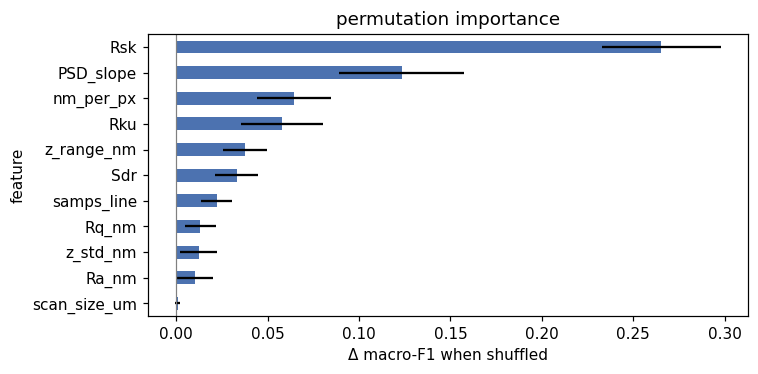


selected (11/11): ['Rsk', 'PSD_slope', 'nm_per_px', 'Rku', 'z_range_nm', 'Sdr', 'samps_line', 'Rq_nm', 'z_std_nm', 'Ra_nm', 'scan_size_um']
macro-F1: all=0.609  selected=0.643


In [29]:
ALL_COLS = list(FEATURE_COLS)

# (i) ANOVA F-test ranking — model-agnostic univariate scores.
f_scores, f_pvals = f_classif(X_all, Y)
fs_table = (pd.DataFrame({'feature': ALL_COLS, 'F': f_scores, 'p': f_pvals})
            .sort_values('F', ascending=False))

# (ii) Permutation importance on the regularised RF — model-aware,
# robust to correlated features (impurity importance is biased on small data).
rf_full = _pipe(CLASSIFIERS['RandomForest']).fit(X_all, Y)
perm = permutation_importance(rf_full, X_all, Y, n_repeats=20,
                              random_state=SEED, scoring='f1_macro', n_jobs=-1)
pi_table = (pd.DataFrame({'feature':   ALL_COLS,
                          'perm_mean': perm.importances_mean,
                          'perm_std':  perm.importances_std})
            .sort_values('perm_mean', ascending=False))

print('ANOVA F:'); print(fs_table.to_string(index=False))
print('\nPermutation importance (Δmacro-F1):'); print(pi_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
pi_table.plot.barh(x='feature', y='perm_mean', xerr='perm_std',
                   ax=ax, color='#4c72b0', legend=False)
ax.invert_yaxis(); ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel('Δ macro-F1 when shuffled'); ax.set_title('permutation importance')
plt.tight_layout(); plt.show()

# (iii) Selection rule: positive permutation importance, else top-5 fallback.
selected = (pi_table.query('perm_mean > 0').feature.tolist()
            or pi_table.head(5).feature.tolist())
print(f"\nselected ({len(selected)}/{len(ALL_COLS)}): {selected}")

# (iv) CV the reduced pipeline against the full one to confirm we
# didn't kneecap the model.
sel_idx = [ALL_COLS.index(c) for c in selected]
X_sel = X_all[:, sel_idx]
f1_full = float(np.mean(cross_val_score(_pipe(CLASSIFIERS['RandomForest']),
                                        X_all, Y, cv=skf, scoring='f1_macro')))
f1_sel  = float(np.mean(cross_val_score(_pipe(CLASSIFIERS['RandomForest']),
                                        X_sel, Y, cv=skf, scoring='f1_macro')))
print(f"macro-F1: all={f1_full:.3f}  selected={f1_sel:.3f}")


## 2.4 Save deployed model

Re-fit the regularised RF on the full dataset (selected feature subset only)
and dump it so `tearcls.server` can load it. Per-column training medians
travel with the checkpoint so single-sample inference can fill NaN the same
way `_materialise` did at training time.

In [30]:
import joblib
from datetime import datetime

best = Pipeline([('scale', StandardScaler()),
                 ('clf',   clone(CLASSIFIERS['RandomForest']))]).fit(X_sel, Y)

# Per-column medians for inference-time NaN fill (training analogue is
# _materialise's df.fillna(median) at the joint feature-space cell).
feature_medians = (meta_df[ALL_COLS]
                   .apply(pd.to_numeric, errors='coerce')
                   .median(numeric_only=True)
                   .to_dict())

ckpt = {
    'pipe':            best,           # expects len(selected) features
    'feature_cols':    ALL_COLS,       # full extractor output (server vectorizes this)
    'selected_cols':   selected,       # subset the pipe was fit on
    'feature_medians': feature_medians,
    'classes':         TARGET_LABELS,
    'trained_at':      datetime.utcnow().isoformat() + 'Z',
    'cv_macro_f1':     f1_sel,
}
out = REPO / 'checkpoints' / 'best.joblib'
out.parent.mkdir(exist_ok=True)
joblib.dump(ckpt, out)
print(f"saved {out}  (cv macro_f1={ckpt['cv_macro_f1']:.3f})")


saved /home/students/xsleher/tear-cls/checkpoints/best.joblib  (cv macro_f1=0.643)


# 3. Evaluation

## 3.1 Score table — features × model

Stratified 5-fold macro F1 pivoted by feature set. `gap` (train − balanced CV)
in the §2.2 table tells you how much each model memorises; here we focus on
generalisation.

macro F1 — stratified 5-fold:
features           all   meta  rough
model                               
1-NN             0.693  0.409  0.591
3-NN             0.500  0.458  0.562
LinearSVC        0.594  0.340  0.593
LogisticReg      0.593  0.363  0.575
NearestCentroid  0.505  0.343  0.534
RandomForest     0.609  0.383  0.588
majority         0.263  0.263  0.263

balanced accuracy — stratified 5-fold:
features           all   meta  rough
model                               
1-NN             0.704  0.422  0.612
3-NN             0.523  0.485  0.576
LinearSVC        0.607  0.393  0.608
LogisticReg      0.728  0.529  0.730
NearestCentroid  0.646  0.376  0.703
RandomForest     0.658  0.428  0.618
majority         0.333  0.333  0.333


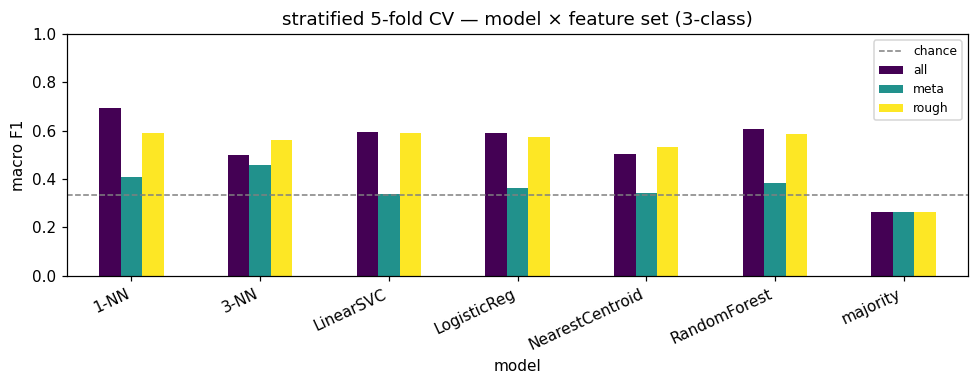

In [31]:
piv_f1  = results.pivot(index='model', columns='features', values='macro_f1').round(3)
piv_bal = results.pivot(index='model', columns='features', values='bal_acc').round(3)
print('macro F1 — stratified 5-fold:')
print(piv_f1.to_string())
print('\nbalanced accuracy — stratified 5-fold:')
print(piv_bal.to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
piv_f1.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylim(0, 1); ax.set_ylabel('macro F1')
ax.set_title('stratified 5-fold CV — model × feature set (3-class)')
ax.axhline(1.0 / len(TARGET_LABELS), ls='--', c='grey', lw=1, label='chance')
ax.legend(fontsize=8); plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()


## 3.2 Confusion matrix — best model

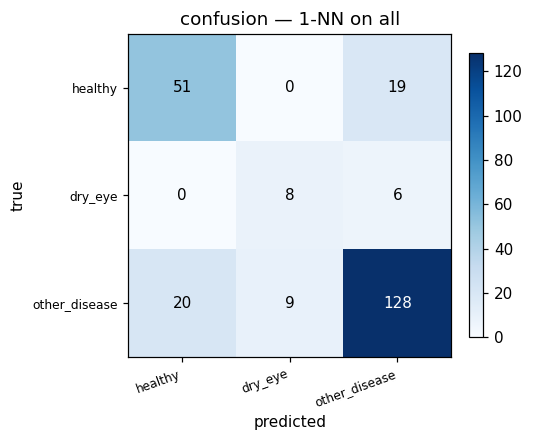

               precision    recall  f1-score   support

      healthy       0.72      0.73      0.72        70
      dry_eye       0.47      0.57      0.52        14
other_disease       0.84      0.82      0.83       157

     accuracy                           0.78       241
    macro avg       0.68      0.71      0.69       241
 weighted avg       0.78      0.78      0.78       241



In [32]:
best_row = results.sort_values('macro_f1', ascending=False).iloc[0]
key = (best_row.features, best_row.model)
yt, yp = oof[key]
cm = confusion_matrix(yt, yp, labels=range(len(TARGET_LABELS)))

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap='Blues'); plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_xticks(range(len(TARGET_LABELS))); ax.set_yticks(range(len(TARGET_LABELS)))
ax.set_xticklabels(TARGET_LABELS, rotation=20, ha='right', fontsize=8)
ax.set_yticklabels(TARGET_LABELS, fontsize=8)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=10)
ax.set_title(f"confusion — {best_row.model} on {best_row.features}")
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()
print(classification_report(yt, yp, target_names=TARGET_LABELS,
                            labels=range(len(TARGET_LABELS)), zero_division=0))


## 3.3 Overfitting sanity — label shuffle + learning curves

For 3-class, **chance = 1/3 ≈ 0.33 balanced accuracy**.

1. **Label-shuffle control**: a model fit on randomly permuted labels should
   score ≈ 0.33. Anything higher means capacity overfit to noise.
2. **Learning curves**: train vs CV balanced-accuracy against training-set
   size — a gap that stays open at full data is classic capacity overfit.

> **RF note:** we cap `max_depth=6`, `min_samples_leaf=3`. Without these
> limits, train_acc → 1.0 while CV sits on the 1/3 chance line — a pure
> overfit signature.

label-shuffle balanced accuracy (expect ≈ 0.33 for 3 classes):
features        all   meta  rough
model                            
LinearSVC     0.322  0.341  0.298
LogisticReg   0.250  0.286  0.351
RandomForest  0.332  0.280  0.351


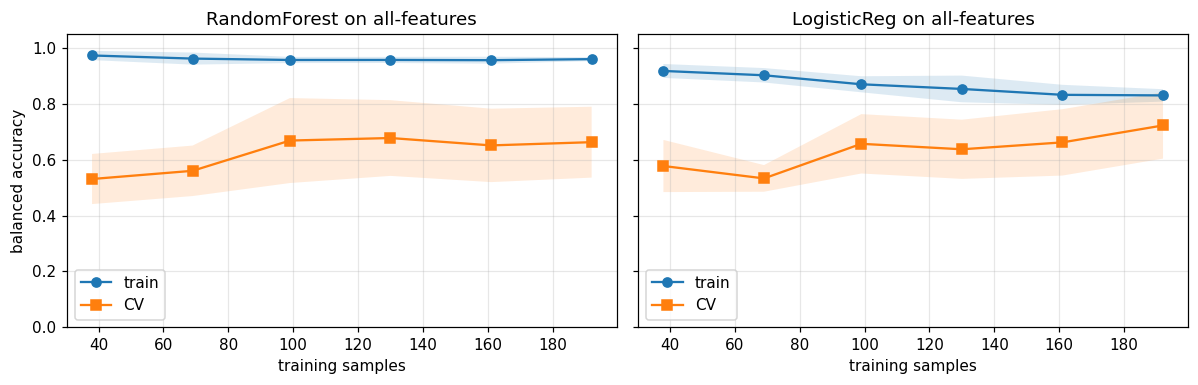

In [33]:
Y_shuf = RNG.permutation(Y)
shuf_rows = []
for name in ('LogisticReg', 'RandomForest', 'LinearSVC'):
    for fs_name, X in FEATURE_SETS.items():
        s = float(np.mean(cross_val_score(_pipe(CLASSIFIERS[name]), X, Y_shuf,
                                          cv=skf, scoring='balanced_accuracy')))
        shuf_rows.append({'model': name, 'features': fs_name, 'shuf_bal_acc': round(s, 3)})
shuf_df = pd.DataFrame(shuf_rows).pivot(index='model', columns='features', values='shuf_bal_acc')
print('label-shuffle balanced accuracy (expect ≈ 0.33 for 3 classes):')
print(shuf_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, name in zip(axes, ('RandomForest', 'LogisticReg')):
    sizes, tr_sc, te_sc = learning_curve(
        _pipe(CLASSIFIERS[name]), X_all, Y,
        train_sizes=np.linspace(0.2, 1.0, 6), cv=skf,
        scoring='balanced_accuracy', random_state=SEED, shuffle=True,
    )
    ax.plot(sizes, tr_sc.mean(1), 'o-', label='train')
    ax.plot(sizes, te_sc.mean(1), 's-', label='CV')
    ax.fill_between(sizes, tr_sc.mean(1) - tr_sc.std(1), tr_sc.mean(1) + tr_sc.std(1), alpha=0.15)
    ax.fill_between(sizes, te_sc.mean(1) - te_sc.std(1), te_sc.mean(1) + te_sc.std(1), alpha=0.15)
    ax.set_title(f'{name} on all-features'); ax.set_xlabel('training samples')
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('balanced accuracy')
plt.tight_layout(); plt.show()


## 3.4 Clustering — unsupervised lower bound

KMeans (k=3) on standardised features. ARI = 0 means clusters are random
w.r.t. the target labels. If ARI is near zero on `all`-features but our
classifiers score well, the information is present but **not along the axes
of highest variance**; the classifier needs supervision to find it.

In [34]:
clust_rows = []
for fs_name, X in FEATURE_SETS.items():
    Xs_ = StandardScaler().fit_transform(X)
    labs = KMeans(n_clusters=len(TARGET_LABELS), n_init=10, random_state=SEED).fit_predict(Xs_)
    clust_rows.append({
        'features':   fs_name,
        'ARI':        round(adjusted_rand_score(Y, labs), 3),
        'NMI':        round(normalized_mutual_info_score(Y, labs), 3),
        'silhouette': round(silhouette_score(Xs_, labs), 3),
    })
print(pd.DataFrame(clust_rows).to_string(index=False))

best_fs = max(clust_rows, key=lambda r: r['ARI'])['features']
Xs_best = StandardScaler().fit_transform(FEATURE_SETS[best_fs])
km = KMeans(n_clusters=len(TARGET_LABELS), n_init=10, random_state=SEED).fit(Xs_best)
ct = pd.crosstab(
    pd.Series([TARGET_LABELS[y] for y in Y], name='true'),
    pd.Series(km.labels_, name='cluster'),
)
print(f'\nKMeans cluster × true target (features={best_fs}):')
print(ct.to_string())


features    ARI   NMI  silhouette
    meta -0.024 0.006       0.423
   rough  0.022 0.161       0.338
     all  0.024 0.081       0.238

KMeans cluster × true target (features=all):
cluster         0   1   2
true                     
dry_eye         2  10   2
healthy         8   8  54
other_disease  29  59  69


### Takeaways

- Leakage audit (§1.4) tells you whether a pixel-based model can be trusted
  against header shortcuts.
- Roughness metrics (§1.5) are what Gwyddion would report — scale-aware
  because we pass `nm_per_px` from the Bruker header.
- Modeling (§2) operates on tabular features *only* — the spreadsheet baseline
  the CNN in `tearcls/` must beat to claim it has learned tear-film morphology
  rather than scanner artefacts.
- The `gap` column in §2.2 is the main overfit diagnostic; §3.3 shuffle +
  learning curves are the sanity checks.